HOUSE PRICE PREDICTION USING REGRESSION MODELS

Model Comparison

               Model  R2 Score      RMSE
0  Linear Regression    0.4019  570.8704
1   Ridge Regression    0.4019  570.8683
2   Lasso Regression    0.4019  570.8847

Best Model
Model       Linear Regression
R2 Score               0.4019
RMSE                 570.8704
Name: 0, dtype: object


C:\Users\anits-csm\anaconda3\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.54318e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


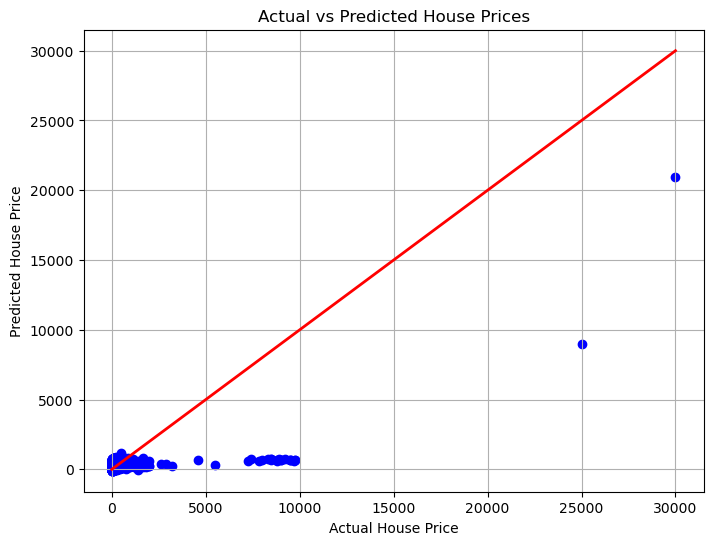

In [3]:
# ==========================================
# LAB 10
# House Price Prediction using Regression Models
# ==========================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error

# Load Dataset
df = pd.read_csv("train.csv")

# Remove missing values
df = df.dropna()

# Drop ADDRESS column (too many unique values)
df = df.drop("ADDRESS", axis=1)

# Convert text columns into numbers
le = LabelEncoder()

df["POSTED_BY"] = le.fit_transform(df["POSTED_BY"])
df["BHK_OR_RK"] = le.fit_transform(df["BHK_OR_RK"])

# Features and Target
X = df.drop("TARGET(PRICE_IN_LACS)", axis=1)
y = df["TARGET(PRICE_IN_LACS)"]

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create Models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1)
}

results = []

print("="*55)
print("HOUSE PRICE PREDICTION USING REGRESSION MODELS")
print("="*55)

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append([name, round(r2,4), round(rmse,4)])

# Display Results
results_df = pd.DataFrame(results,
                          columns=["Model","R2 Score","RMSE"])

print("\nModel Comparison\n")
print(results_df)

# Best Model
best = results_df.loc[results_df["R2 Score"].idxmax()]

print("\nBest Model")
print(best)

# ---------------- Graph ----------------

linear = LinearRegression()

linear.fit(X_train, y_train)

pred = linear.predict(X_test)

plt.figure(figsize=(8,6))

plt.scatter(y_test, pred, color="blue")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.title("Actual vs Predicted House Prices")
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.grid(True)

plt.show()

First 5 Rows
  POSTED_BY  UNDER_CONSTRUCTION  RERA  BHK_NO. BHK_OR_RK    SQUARE_FT  \
0     Owner                   0     0        2       BHK  1300.236407   
1    Dealer                   0     0        2       BHK  1275.000000   
2     Owner                   0     0        2       BHK   933.159722   
3     Owner                   0     1        2       BHK   929.921143   
4    Dealer                   1     0        2       BHK   999.009247   

   READY_TO_MOVE  RESALE                      ADDRESS  LONGITUDE   LATITUDE  \
0              1       1        Ksfc Layout,Bangalore  12.969910  77.597960   
1              1       1    Vishweshwara Nagar,Mysore  12.274538  76.644605   
2              1       1             Jigani,Bangalore  12.778033  77.632191   
3              1       1  Sector-1 Vaishali,Ghaziabad  28.642300  77.344500   
4              0       1             New Town,Kolkata  22.592200  88.484911   

   TARGET(PRICE_IN_LACS)  
0                   55.0  
1                  

C:\Users\anits-csm\anaconda3\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.54318e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)



Best Model
Model       Ridge Regression
R2 Score             0.40189
RMSE              570.868335
Name: 1, dtype: object


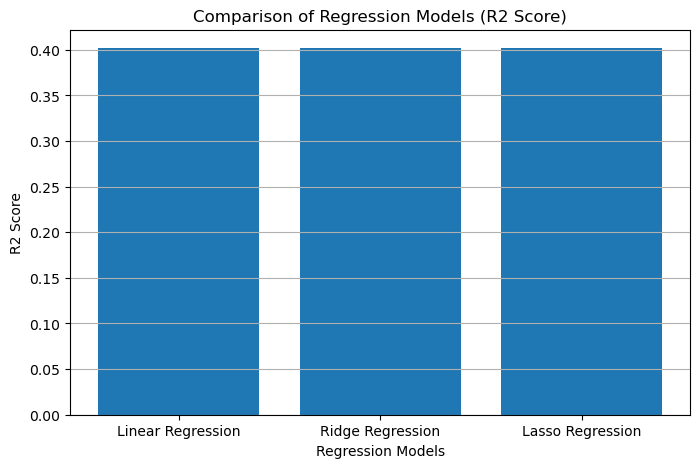

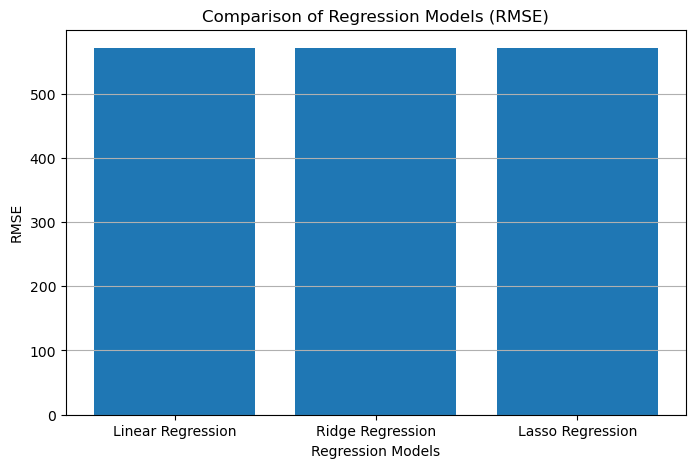

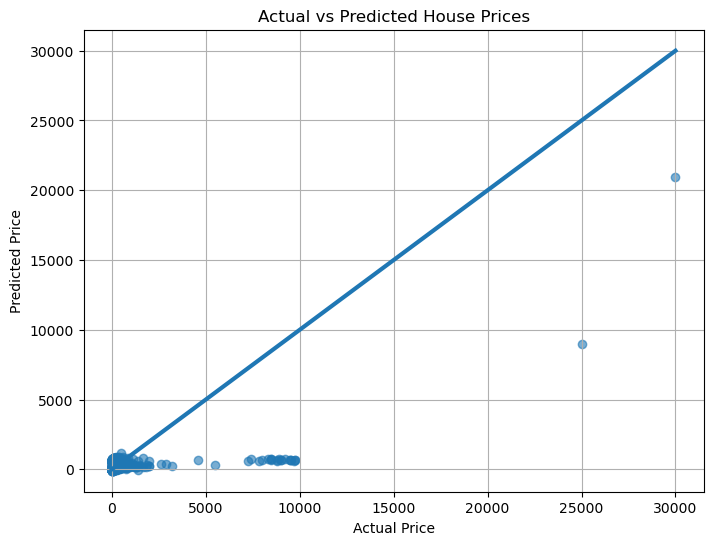

In [4]:
# =====================================================
# LAB 10
# House Price Prediction using Different Regression Models
# =====================================================

# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error

# Step 2: Load Dataset
df = pd.read_csv("train.csv")

# Step 3: Display Dataset
print("First 5 Rows")
print(df.head())

print("\nDataset Shape:", df.shape)

# Step 4: Remove Missing Values
df.dropna(inplace=True)

# Step 5: Drop ADDRESS Column (Large text column)
df.drop("ADDRESS", axis=1, inplace=True)

# Step 6: Convert Text Columns into Numbers
le = LabelEncoder()

df["POSTED_BY"] = le.fit_transform(df["POSTED_BY"])
df["BHK_OR_RK"] = le.fit_transform(df["BHK_OR_RK"])

# Step 7: Features and Target
X = df.drop("TARGET(PRICE_IN_LACS)", axis=1)

y = df["TARGET(PRICE_IN_LACS)"]

# Step 8: Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Step 9: Create Models
linear = LinearRegression()
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=0.1)

models = {
    "Linear Regression": linear,
    "Ridge Regression": ridge,
    "Lasso Regression": lasso
}

results = []

print("\n")
print("="*60)
print("MODEL COMPARISON")
print("="*60)

# Step 10: Train Models
for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append([name, r2, rmse])

    print("\n", name)
    print("R2 Score :", round(r2,4))
    print("RMSE     :", round(rmse,4))

# Step 11: Results Table
results_df = pd.DataFrame(
    results,
    columns=["Model","R2 Score","RMSE"]
)

print("\n")
print(results_df)

# Step 12: Best Model
best = results_df.loc[results_df["R2 Score"].idxmax()]

print("\nBest Model")
print(best)

# =====================================================
# GRAPH 1 : R2 SCORE COMPARISON
# =====================================================

plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["R2 Score"])

plt.title("Comparison of Regression Models (R2 Score)")
plt.xlabel("Regression Models")
plt.ylabel("R2 Score")

plt.grid(axis="y")

plt.show()

# =====================================================
# GRAPH 2 : RMSE COMPARISON
# =====================================================

plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["RMSE"])

plt.title("Comparison of Regression Models (RMSE)")
plt.xlabel("Regression Models")
plt.ylabel("RMSE")

plt.grid(axis="y")

plt.show()

# =====================================================
# GRAPH 3 : ACTUAL VS PREDICTED
# =====================================================

linear.fit(X_train, y_train)

pred = linear.predict(X_test)

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    pred,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linewidth=3
)

plt.title("Actual vs Predicted House Prices")

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.grid(True)

plt.show()